# TASK 9p SIT 720

In [1]:
import numpy as np
import pandas as pd

df = pd.read_excel("/users/tysonmitchell/Downloads/NF_dataset.xlsx")
df = df.drop(columns=["Unnamed: 0"])
print(df.head())
print(df.shape)

   Case Type  Tumour Case  Age of Mother  Age of Father  \
0          0            1           30.0           31.0   
1          0            1           22.0           29.0   
2          1            1           28.0           26.0   
3          0            1           30.0           34.0   
4          0            1           27.0           34.0   

   Age at First Diagnosis  Café au lait (CLS)  Axillary Freckles  \
0                     5.0                   0                  0   
1                     7.0                   1                  1   
2                     9.0                   1                  1   
3                     9.0                   1                  1   
4                     1.0                   1                  1   

   Inguinal Freckles  Lisch Nodules  Dermal Neurofibromins  \
0                  0              0                      0   
1                  0              0                      1   
2                  0              0               

In [2]:
print("How many values are null in individual columns or attribute\n",df.isnull().sum())

How many values are null in individual columns or attribute
 Case Type                    0
Tumour Case                  0
Age of Mother               35
Age of Father               34
Age at First Diagnosis       4
Café au lait (CLS)           0
Axillary Freckles            0
Inguinal Freckles            0
Lisch Nodules                0
Dermal Neurofibromins        0
Plexiform Neurofibromins     0
Optic Glioma                 0
Skeletal Dysplasia           0
Learning Disability          0
Hypertension                 0
Astrocytoma                  0
Hamartoma                    0
Scoliosis                    0
Other Symptoms               0
dtype: int64


In [3]:
df2 = df.copy()
df2.fillna(df.median(numeric_only=True), inplace=True) #as we can see, the only features with null values are age so we will use median to replace these
print("How many values are now null in individual columns or attribute\n",df2.isnull().sum())

How many values are now null in individual columns or attribute
 Case Type                   0
Tumour Case                 0
Age of Mother               0
Age of Father               0
Age at First Diagnosis      0
Café au lait (CLS)          0
Axillary Freckles           0
Inguinal Freckles           0
Lisch Nodules               0
Dermal Neurofibromins       0
Plexiform Neurofibromins    0
Optic Glioma                0
Skeletal Dysplasia          0
Learning Disability         0
Hypertension                0
Astrocytoma                 0
Hamartoma                   0
Scoliosis                   0
Other Symptoms              0
dtype: int64


<Axes: xlabel='Tumour Case', ylabel='count'>

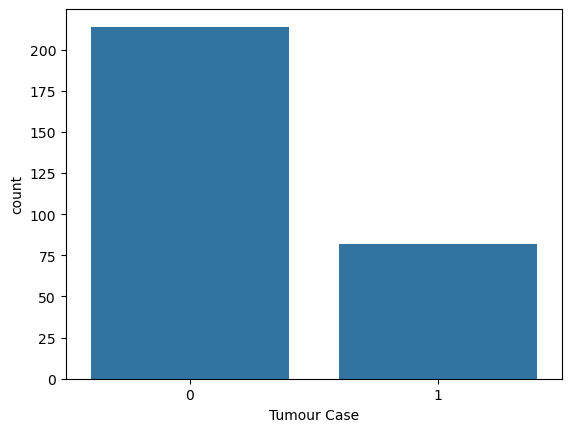

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Tumour Case', data=df2)

In [5]:
from sklearn.model_selection import train_test_split

X = df2.drop('Tumour Case', axis=1)
y = df['Tumour Case']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn import tree

# fit a classification tree with max_depth=5
from sklearn.tree import DecisionTreeClassifier
treeclf = DecisionTreeClassifier(random_state=42)

# Fit our training data
treeclf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pred_tree = treeclf.predict(X_test)

print(classification_report(y_test, pred_tree))
print("Training accuracy: {}".format(accuracy_score(y_train, treeclf.predict(X_train))))
print("Testing accuracy : {}".format(accuracy_score(y_test, treeclf.predict(X_test))))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        42
           1       0.81      0.72      0.76        18

    accuracy                           0.87        60
   macro avg       0.85      0.83      0.84        60
weighted avg       0.86      0.87      0.86        60

Training accuracy: 1.0
Testing accuracy : 0.8666666666666667


As expected, our training accuracy is 100% with no set paramaters, while the testing accuracy is 87%. For our classification report, we have an f1 score of 0.91 for no tumour and 0.76 for tumour cases, indicating that our model is predicting no tumour more than the presence of a tumour due to imbalanced classes, leading to a lower f1 score for tumour compared to no tumour. 

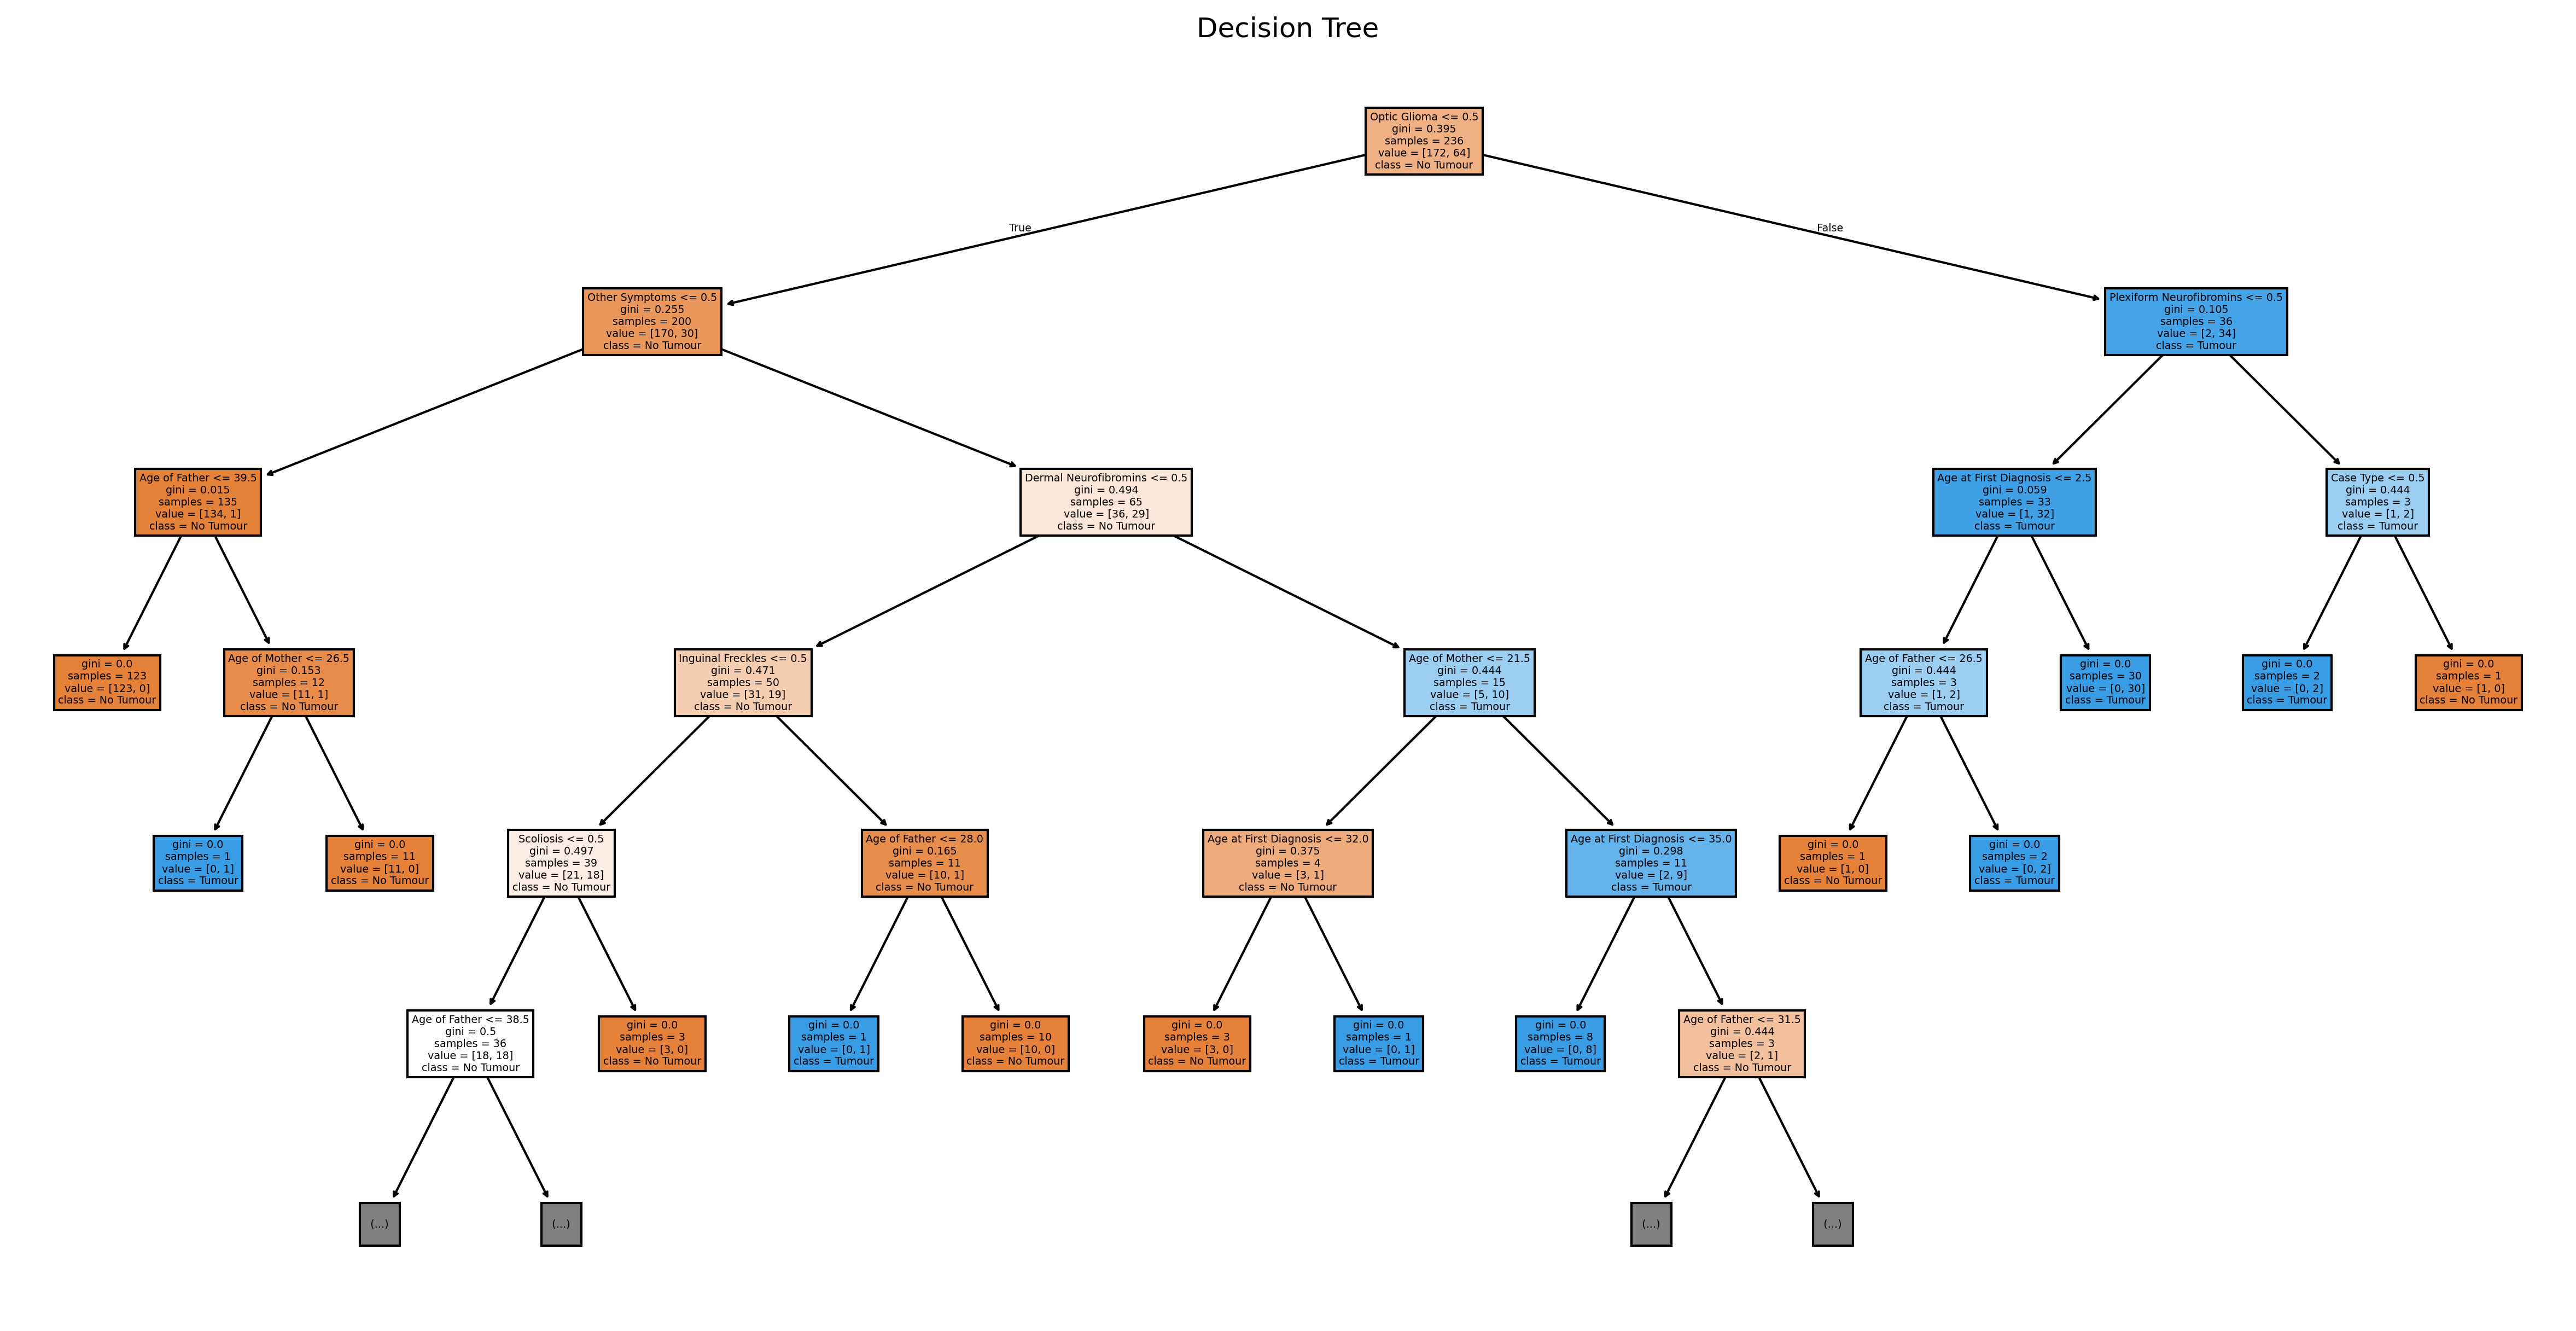

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 10), dpi=300)
plot_tree(treeclf,
          feature_names=X.columns,
          class_names=["No Tumour", "Tumour"],
          filled=True,
          max_depth=5,        # limit depth so it's readable
          ax=ax)
plt.title("Decision Tree")
plt.show()

From our tree, we can see that the feature is Optic Glioma ≤ 0.5. At the root, the gini score is 0.395, but it decreases to 0.255 for other symptoms and 0.105 for Plexiform Neurofibromins after splitting. Now, we will see how changing the depth of the trees will impact the model. 

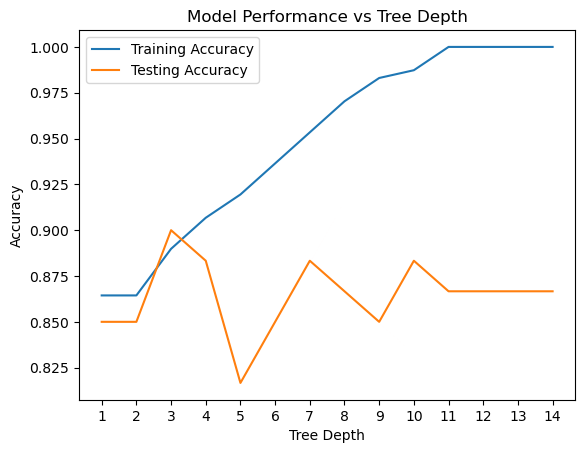

In [9]:
depths = range(1, 15)
train_scores = []
test_scores = []

for depth in depths:
    tree_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_depth.fit(X_train, y_train)
    
    train_scores.append(accuracy_score(y_train, tree_depth.predict(X_train)))
    test_scores.append(accuracy_score(y_test, tree_depth.predict(X_test)))

plt.plot(depths, train_scores, label="Training Accuracy")
plt.plot(depths, test_scores, label="Testing Accuracy")
plt.xticks(range(1,15))
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Model Performance vs Tree Depth")
plt.legend()
plt.show()

As we can see, a low tree depth has a high bias and leads to underfitting, while a high tree depth has a high variance which leads to overfitting, as we can see that a depth of 11 and greater leads approaches a 100% fitting accuracy. The best result in terms of the bias-variance trade-off is the tree depth where test accuracy as at is peak, which we can see occurs at a depth of 3. Here, the depth is at an optimal range where the model has neither high bias or variance, and the model is the best fit for our data. 

In [10]:
optimal_depth = tree_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
optimal_depth.fit(X_train, y_train)

print(f"Training accuracy: {accuracy_score(y_train, optimal_depth.predict(X_train))}")
print(f"Testing accuracy: {accuracy_score(y_test, optimal_depth.predict(X_test))}")
print(classification_report(y_test, optimal_depth.predict(X_test)))

Training accuracy: 0.8898305084745762
Testing accuracy: 0.9
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.88      0.78      0.82        18

    accuracy                           0.90        60
   macro avg       0.89      0.87      0.88        60
weighted avg       0.90      0.90      0.90        60



Now, we will build an optimal random forest model to compare with our best decision tree model.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [50, 100, 200, 500, 750, 1000], #setting around the default of 100, and found after a few attempts that higher estimators performed better here 
    'max_depth': [1, 3, 5, 7, 9, 11, 13, 15] #for our small dataset and 3 was optimal before in decision tree
}

grid_rf_f1 = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf, 
    cv=5,               
    scoring='f1',
    n_jobs=-1
)

grid_rf_acc = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf, 
    cv=5,               
    scoring='accuracy',
    n_jobs=-1
)


grid_rf_f1.fit(X_train, y_train)
grid_rf_acc.fit(X_train, y_train)

print("Best Random Forest params (f1):", grid_rf_f1.best_params_)
print("Best Random Forest F1:", grid_rf_f1.best_score_)
print(classification_report(y_test, grid_rf_f1.predict(X_test)))

print("Best Random Forest params (Accuracy):", grid_rf_acc.best_params_)
print("Best Random Forest Accuracy:", grid_rf_acc.best_score_)
print(classification_report(y_test, grid_rf_acc.predict(X_test)))

print("Results from decision tree where max_depth = 3")
print(classification_report(y_test, optimal_depth.predict(X_test)))

Best Random Forest params (f1): {'max_depth': 11, 'n_estimators': 500}
Best Random Forest F1: 0.7275374982192162
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        42
           1       0.93      0.72      0.81        18

    accuracy                           0.90        60
   macro avg       0.91      0.85      0.87        60
weighted avg       0.90      0.90      0.90        60

Best Random Forest params (Accuracy): {'max_depth': 11, 'n_estimators': 500}
Best Random Forest Accuracy: 0.8642730496453901
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        42
           1       0.93      0.72      0.81        18

    accuracy                           0.90        60
   macro avg       0.91      0.85      0.87        60
weighted avg       0.90      0.90      0.90        60

Results from decision tree where max_depth = 3
              precision    recall  f1-score   support

      

When doing the analysis, I could not decide on a performance metric to choose the right hyperparamters. I included accuracy to be consistent as this was used for decision tree depth, but I also felt that f1 score was important for measuring performance in a classification task. From both, we can see that the best parameters are identical: max depth of 11 and n_estimators of 500. This returned an f1 score of 0.93 for no tumour and 0.81 for tumour cases. As we can see, the f1 for no tumour cases is the same as our decision tree model, however the f1 score for tumour cases was lower (0.81 vs 0.82). When looking at recall, we can see that the random forest model had only 0.72 compared to 0.78 of the decision tree. Our dataset is relatively small (60 test samples), but our optimal model was found to have a high max depth and number of trees. There were only 18 tumour cases, and so each tree would have seen very few if any tumour cases. This lead to the model predicting no tumour at a higher frequency, which we can see in the recall of 0.72. Therefore, hypertuning the paramters for random forest model may have lead to a high model complexity and increased overfitting of the model. 

In [12]:
from sklearn.ensemble import AdaBoostClassifier

param_boost = {
    'n_estimators': [50, 100, 200, 500, 750, 1000], #same as before  
    'learning_rate': [0.01, 0.1, 0.5, 1.0] 
}

grid_boost = GridSearchCV(
    AdaBoostClassifier(random_state=42), 
    param_boost, 
    cv=5,               
    scoring='f1',
    n_jobs=-1
)

grid_boost.fit(X_train, y_train)
print("Best AdaBoost params:", grid_boost.best_params_)
print("Best AdaBoost score:", grid_boost.best_score_)
print(classification_report(y_test, grid_boost.predict(X_test)))

Best AdaBoost params: {'learning_rate': 0.1, 'n_estimators': 750}
Best AdaBoost score: 0.7013593073593074
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.88      0.78      0.82        18

    accuracy                           0.90        60
   macro avg       0.89      0.87      0.88        60
weighted avg       0.90      0.90      0.90        60



In order to select our best Boosting model, we have used f1 as our scoring metric instead of accuracy to better identify the classification of our imbalanced classes. As we can see, Boosting had an f1 score of 0.93 for no tumour and 0.82 for tumour cases. Compared to bagging (Random Forest), we had an f1 of 0.93 for no tumour and 0.81 for tumour cases. As we can see, boosting lead to a higher f1 score for tumour cases, and a noticeably higher recall for tumour cases compared to bagging (0.78 vs 0.72). Therefore, boosting is more suitable for this prediction task. 